**Table of contents**<a id='toc0_'></a>    
- [Imports](#toc1_)    
- [Load Data set](#toc2_)    
- [Understanding Data](#toc3_)    
- [Global constants](#toc4_)    
- [Helper methods](#toc5_)    
  - [Confusion matrix](#toc5_1_)    
  - [2D Scatterplot for cluster visualization](#toc5_2_)    
  - [Image agumentation](#toc5_3_)    
- [Model 1 - Classification](#toc6_)    
  - [Selecting 5 categories and labels](#toc6_1_)    
  - [Split data to train(fit) and test(predict)](#toc6_2_)
  - [Data reshape](#toc6_3_)    
  - [Logistic regression](#toc6_4_)    
    - [Without hyperparamter tuning](#toc6_4_1_)  
    - [With Normalization and hyperparameter tuning](#toc6_4_2_)    
  - [SVM](#toc6_5_)    
    - [Without hyperparamter tuning](#toc6_5_1_)    
    - [With Normalization and hyper parameter tuning](#toc6_5_2_)    
- [Model 2 - Preprocessing with classification](#toc7_)    
  - [Pre-processing with LDA feature/dimensionality reduction](#toc7_1_) 
  - [Pre-processing with HOG feature extraction reduction](#toc7_2_)
- [Model 3 - CNN](#toc8_)    
  - [Model 3A - CNN without data agumentation](#toc8_1_)    
    - [Split Data and its overview](#toc8_1_1_)    
    - [CNN](#toc8_1_2_)    
    - [Confusion matrix and visualisations](#toc8_1_3_)    
  - [Model 3B - CNN with data agumentation](#toc8_2_)    
    - [Split agumented data](#toc8_2_1_)
    - [CNN defination and training](#toc8_2_4_)    
    - [Confusion matrix and accuracy curves](#toc8_2_5_)

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Imports](#toc0_)

In [2]:
from matplotlib import pyplot as plt

import numpy as np
import pandas as pd

import seaborn as sns

import skimage.feature

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.svm import SVC

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping #type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator #type: ignore

# <a id='toc2_'></a>[Load Data set](#toc0_)

In [3]:
land_cover_data = np.load('./Datasets/DS_Xdata.npy')
land_cover_labels = np.load('./Datasets/Ydata.npy')

# <a id='toc3_'></a>[Understanding Data](#toc0_)

In [4]:
print(f"Shape: {land_cover_data.shape}")
print(f"Sample count: {len(land_cover_labels)}")
print(f"Unique label: {np.unique(land_cover_labels)}")

Shape: (2100, 61, 61, 3)
Sample count: 2100
Unique label: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


# <a id='toc4_'></a>[Global constants](#toc0_)

In [5]:
#Value to replicate the random value generation(s) and results in the file
seeding_constant = 20

#Categories to be selected for classification for model 1 and model 2
category_count = 5

#Define all the strings as labels
label_classes = ['agricultural', 'airplane', 
                 'baseball diamond', 'beach', 
                 'buildings', 'chaparral', 
                 'dense residential', 'forest', 
                 'freeway', 'golf course',
                 'harbour', 'intersection', 
                 'medium residential', 'mobile home park',
                 'overpass', 'parking lot', 
                 'river', 'runway', 'sparse residential', 
                 'storage tanks', 'tennis court'
                ]

# <a id='toc5_'></a>[Helper methods](#toc0_)

## <a id='toc5_1_'></a>[Confusion matrix](#toc0_)

In [6]:
def confusion_matrix_helper(trueLabels, 
                            predictedlabels, 
                            title,
                            figure_size=(8,6), 
                            color_map="Blues"
                            ):
    """
    Generates and visualizes a normalized confusion matrix as a heatmap.

    Parameters:
        trueLabels (array-like): Array of ground truth (true) labels.
        predictedlabels (array-like): Array of predicted labels.
        title (str): Title for the confusion matrix plot.
        figure_size (tuple, optional): Size of the figure in inches. Default is (8, 6).
        color_map (str, optional): Colormap to use for the heatmap. Default is "Blues".

    Displays:
        A heatmap of the normalized confusion matrix with annotations.
    """

    plt.ion()
    matrix_array = confusion_matrix(trueLabels, predictedlabels)

    cm_normalized = matrix_array.astype('float') / matrix_array.sum(axis=1, keepdims=True) * 100

    # Create a DataFrame for better visualization
    labels = []
    for i in np.unique(trueLabels):
        labels.append(label_classes[i])

    cm_df = pd.DataFrame(cm_normalized, index=labels, columns=labels)

    # Plot the heatmap
    plt.figure(figsize=figure_size)
    sns.heatmap(cm_df, annot=True, fmt=".2f", cmap=color_map, cbar_kws={'label': 'Percentage (%)'})

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    
    plt.show()

In [7]:
def confusion_matrix_helper_threshold(trueLabels, 
                            predictedlabels, 
                            title, 
                            label_classes,
                            figure_size=(8,6), 
                            color_map="Blues",
                            operator = 'GTE',
                            threshold=50):
    """
    Generates and visualizes a normalized confusion matrix as a heatmap.

    Parameters:
        trueLabels (array-like): Array of ground truth (true) labels.
        predictedlabels (array-like): Array of predicted labels.
        title (str): Title for the confusion matrix plot.
        label_classes: To provide string for labels.
        figure_size (tuple, optional): Size of the figure in inches. Default is (8, 6).
        color_map (str, optional): Colormap to use for the heatmap. Default is "Blues".
        operator(str, optional): To use for selecting below or above thresold values. Default is'GTE'.
        threshold(int, optional): Comparison metric for delecting display of true labels. Deafult is 50.

    Displays:
        A heatmap of the normalized confusion matrix with annotations.
    """

    plt.ion()
    matrix_array = confusion_matrix(trueLabels, predictedlabels)

    # Compute True Positive Rate (TPR) for each class
    TP = np.diag(matrix_array)  # Diagonal elements are the True Positives
    FN = matrix_array.sum(axis=1) - TP  # False Negatives: sum of row - diagonal
    TPR = TP / (TP + FN) * 100  # True Positive Rate as a percentage

    low_tpr_classes = np.array([])
    filtered_labels = []
    # Filter the true labels where TPR < threshold
    if operator == 'GTE':
        low_tpr_classes = np.where(TPR >= threshold)[0]  # Find indices where TPR < threshold
        filtered_labels = [label_classes[i] for i in low_tpr_classes]  # Get the corresponding class labels
    else:        
        low_tpr_classes = np.where(TPR <= threshold)[0]  # Find indices where TPR < threshold
        filtered_labels = [label_classes[i] for i in low_tpr_classes]  # Get the corresponding class labels

    # Create a filtered confusion matrix using only the true labels with TPR < threshold
    filtered_matrix = matrix_array[low_tpr_classes, :]  # Filter rows (true labels)

    # Filter out predicted labels where the column sum is zero (no predictions)
    non_zero_columns = np.where(filtered_matrix.sum(axis=0) > 0)[0]  # Columns where the sum is greater than zero

    # Apply the column filter to the matrix
    filtered_matrix = filtered_matrix[:, non_zero_columns]  # Filter columns (predicted labels)

    # Normalize the filtered confusion matrix
    cm_normalized = filtered_matrix.astype('float') / filtered_matrix.sum(axis=1, keepdims=True) * 100

    # Create a DataFrame for better visualization
    cm_df = pd.DataFrame(cm_normalized, index=filtered_labels, columns=[label_classes[i] for i in non_zero_columns])

    # Plot the heatmap
    plt.figure(figsize=figure_size)
    ax = sns.heatmap(cm_df, annot=True, fmt=".2f", cmap=color_map, cbar_kws={'label': 'Percentage (%)'})

    for i in range(len(cm_df)):
        for j in range(len(cm_df.columns)):
        # Compare the true label and predicted label for the same index
            if cm_df.columns[j] == cm_df.index[i]:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='red', lw=2))

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    
    plt.show()


## <a id='toc5_2_'></a>[2D Scatterplot for cluster visualization](#toc0_)

In [8]:
def scatter_plot2D(dataset, 
                   true_labels, 
                   predicted_labels,
                   xaxis_title, 
                   yaxis_title
                   ):
    """
    This function generates a scatter plot of 2D data with true labels and predicted labels.

    Parameters:
        dataset (numpy array): The 2D dataset to be plotted.
        true_labels (numpy array): The true labels of the dataset.
        predicted_labels (numpy array): The predicted labels of the dataset.
        xaxis_title (str): The title of the x-axis.
        yaxis_title (str): The title of the y-axis.

    Displays:
        A scatter plot with true labels and predicted labels.
    """

    # Create a scatter plot with 2D data
    plt.ion()

    # Create a figure with multiple subplots
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    # Plot ground truth
    axs[0].scatter(dataset[:,0], 
                   dataset[:,1],
                   c=true_labels,
                   cmap='Accent'
                   )
    
    axs[0].set_xlabel(xaxis_title)
    axs[0].set_ylabel(yaxis_title)
    axs[0].set_title("Ground Truth")

    #Plot predicted truth
    axs[1].scatter(dataset[:,0], 
                   dataset[:,1],
                   c=predicted_labels,
                   cmap='Accent'
                   )
    
    axs[1].set_xlabel(xaxis_title)
    axs[1].set_ylabel(yaxis_title)
    axs[1].set_title("Predicted Categories")

    # Layout so plots do not overlap
    fig.tight_layout()

    plt.show()

## <a id='toc5_3_'></a>[Image agumentation](#toc0_)

In [9]:
def image_generator(image, num_augmented_images = 5):
    """
    This function generates augmented images using the given image and the specified number of augmented images

    Parameters
        image: The input image to be augmented
        num_augmented_images: The number of augmented images to be generated

    Returns
        all_images_array: Array of augmented images
    """

    # Set up the ImageDataGenerator with your desired augmentations
    datagen = ImageDataGenerator(
        rotation_range=0,             # No random rotations
        shear_range=0.2,              # Shear transformations
        zoom_range=0.2,               # Zoom range (20%)
        horizontal_flip=True,         # Horizontal flip
        vertical_flip=True,           # Vertical flip
        fill_mode='nearest'  # Use custom rotation function
    )

    img_array = np.expand_dims(image, axis=0)  # Add a batch dimension

    # Array to hold augmented images
    augmented_images = []

    # Number of augmented images to generate
    num_augmented_images = 5

    # Generate augmented images and store them in the array
    for batch in datagen.flow(img_array, batch_size=1):
        augmented_images.append(batch[0])  # Add the augmented image to the list
        if len(augmented_images) >= num_augmented_images:
            break  # Stop after generating the desired number of augmented images


    # Convert the list of augmented images to a NumPy array for easier processing
    augmented_images_array = np.array(augmented_images)

    augmented_image_array_270=np.rot90(augmented_images_array, axes=(1,2))
    augmented_image_array_180=np.rot90(augmented_images_array, k=2)
    augmented_image_array_90=np.rot90(augmented_images_array, k=3, axes=(1,2))

    # merge all the images to a single array
    all_images_array = np.concatenate((augmented_images_array, augmented_image_array_90, augmented_image_array_180, augmented_image_array_270))

    return all_images_array


In [ ]:
augmented_images = np.array(np.copy(land_cover_data))
augmented_label_list = np.copy(land_cover_labels).flatten()

for i in range(len(land_cover_data)):
    # Extract the image and its corresponding label
    images_result= image_generator(land_cover_data[i, :, :, :])
    # Append the augmented images to the list
    augmented_images = np.concatenate((augmented_images, images_result))

    repeated_labels = np.repeat(land_cover_labels[i], images_result.shape[0])  # Repeat the label for the batch of images
    
    # Append the repeated labels
    augmented_label_list = np.concatenate((augmented_label_list, repeated_labels))

# <a id='toc6_'></a>[Model 1 - Classification](#toc0_)

## <a id='toc6_1_'></a>[Selecting 5 categories and labels](#toc0_)

In [10]:
#Setting the random seed for reproducibility
np.random.seed(seeding_constant)

#To get list of unique labels
unique_label_set = set(np.unique(land_cover_labels))

selected_categories = [np.random.randint(min(unique_label_set), 
                                         max(unique_label_set)) 
                        for _ in range(category_count)
                        ]

#Filtered categories list for data and labels
selected_land_cover_data = [] 
selected_land_cover_labels = [] 

for index, value in enumerate(land_cover_labels):
    if value[0] in selected_categories:
        selected_land_cover_data.append(land_cover_data[index])
        selected_land_cover_labels.append(value[0])

## <a id='toc6_2_'></a>[Split data to train(fit) and test(predict)](#toc0_)

In [11]:
split_list = train_test_split(selected_land_cover_data,
                              selected_land_cover_labels,
                              test_size = 0.1,
                              shuffle = True,
                              random_state = seeding_constant                                      
                            )

#Train data and labels for model 1 and 2
train_land_cover_data = split_list[0]
train_land_cover_labels = split_list[2]

#Test data and labels for model 1 and 2
test_land_cover_data = split_list[1]
test_land_cover_labels = split_list[3]

### <a id='toc6_2_1_'></a>[Understanding split data](#toc0_)

In [12]:
unique_train_labels = set(np.unique(train_land_cover_labels))

print("Train Data diversification")
for i in unique_train_labels:
    print(f"Label {i} : {train_land_cover_labels.count(i)}")

Train Data diversification
Label 3 : 87
Label 7 : 91
Label 9 : 93
Label 11 : 87
Label 15 : 92


In [13]:
unique_test_labels = np.unique(test_land_cover_labels)
print("Test Data diversification")
for i in unique_test_labels:
    print(f"Label {i} : {test_land_cover_labels.count(i)}")

Test Data diversification
Label 3 : 13
Label 7 : 9
Label 9 : 7
Label 11 : 13
Label 15 : 8


## <a id='toc6_3_'></a>[Data reshape](#toc0_)


In [14]:
# Reshape each image to a 1D array
num_features = np.prod(train_land_cover_data[0].shape) 

train_land_cover_data_reshaped = np.array([x.reshape(num_features) for x in train_land_cover_data])
test_land_cover_data_reshaped = np.array([x.reshape(num_features) for x in test_land_cover_data])

#Reshape the entire dataset for sross validation
selected_land_cover_data_reshaped = np.array([x.reshape(num_features) for x in selected_land_cover_data])

## <a id='toc6_4_'></a>[Logistic regression](#toc0_)

### <a id='toc6_4_1_'></a>[Without hyperparamter tuning](#toc0_)

In [15]:
# Train a classifier on the reduced training data
logistic_classifier1 = LogisticRegression(max_iter=1000)
logistic_classifier1.fit(train_land_cover_data_reshaped, train_land_cover_labels)

# Predict labels for the reduced test data
predicted_labels_lr1 = logistic_classifier1.predict(test_land_cover_data_reshaped)

print("Accuracy:",logistic_classifier1.score(test_land_cover_data_reshaped, test_land_cover_labels))


Accuracy: 0.6


#### <a id='toc6_4_1_1_'></a>[Confusion matrix and other visualizations](#toc0_)

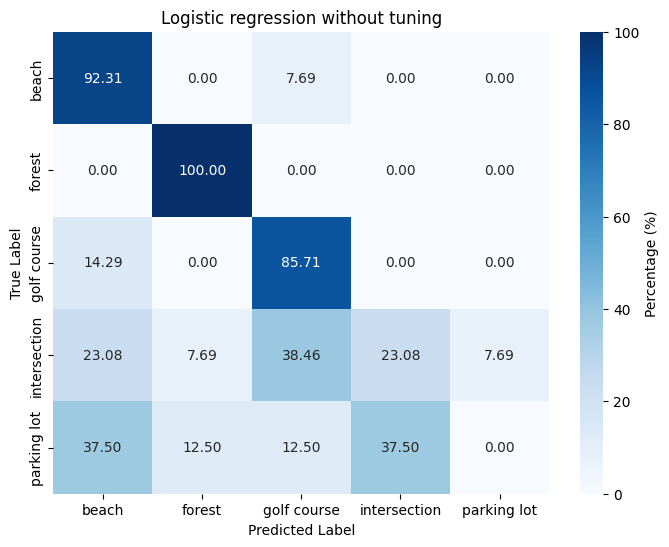

In [16]:
confusion_matrix_helper(test_land_cover_labels, 
                        predicted_labels_lr1, 
                        'Logistic regression without tuning'
                        )

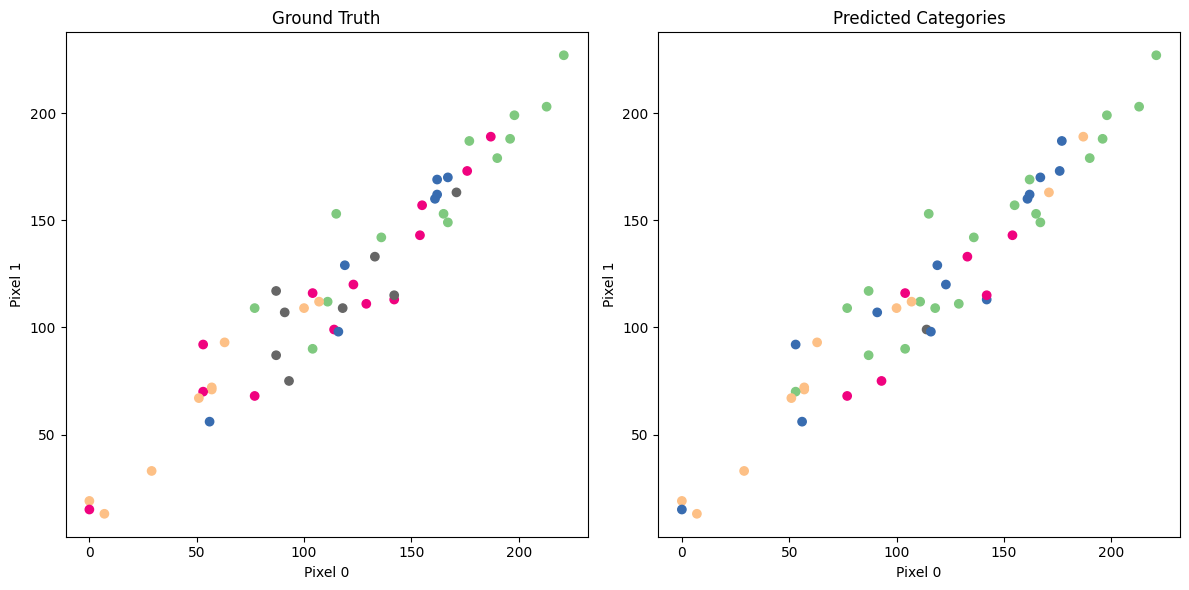

In [17]:
scatter_plot2D(test_land_cover_data_reshaped, 
               test_land_cover_labels, 
               predicted_labels_lr1,
               'Pixel 0',
               'Pixel 1'
               )

### <a id='toc6_4_2_'></a>[With Normalization and hyperparameter tuning](#toc0_)

In [18]:
# Normalize the training and testing data by scaling pixel values to the range [0, 1] by dividing by 255
normalized_train_data = train_land_cover_data_reshaped / 255
normalized_test_data = test_land_cover_data_reshaped / 255

# Train a classifier on the reduced training data
logistic_classifier3 = LogisticRegression(max_iter=1000)
logistic_classifier3.fit(normalized_train_data, train_land_cover_labels)

# Predict labels for the reduced test data
predicted_labels_lr3 = logistic_classifier3.predict(normalized_test_data)

print(logistic_classifier3.score(normalized_test_data, test_land_cover_labels))

0.62


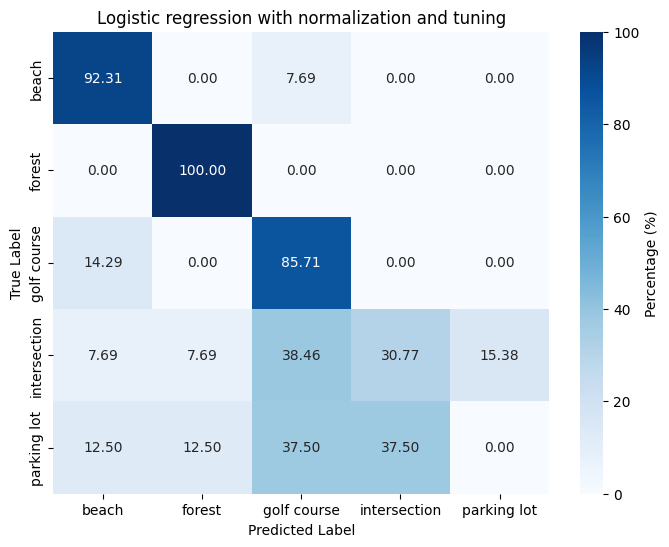

In [19]:
confusion_matrix_helper(test_land_cover_labels, 
                        predicted_labels_lr3, 
                        'Logistic regression with normalization and tuning'
                        )

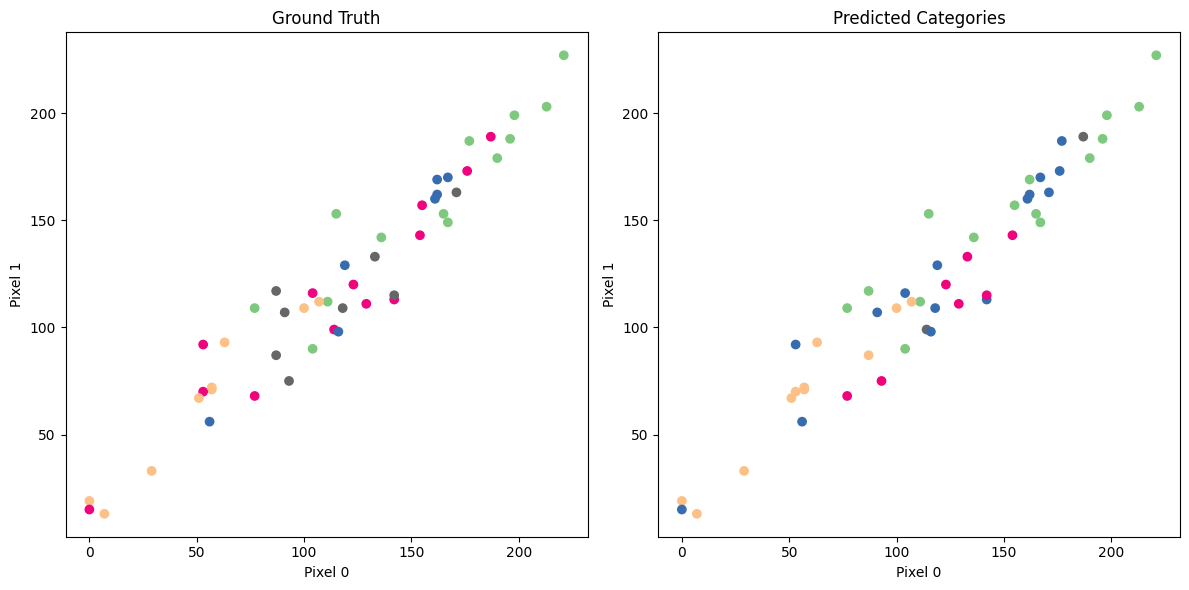

In [ ]:
scatter_plot2D(test_land_cover_data_reshaped, 
               test_land_cover_labels, 
               predicted_labels_lr3,
               'Pixel 0',
               'Pixel 1'
               )

## <a id='toc6_5_'></a>[SVM](#toc0_)

### <a id='toc6_5_1_'></a>[Without hyperparamter tuning](#toc0_)

In [56]:
# Create an instance of the Support Vector Classifier (SVC)
svm1 = SVC()

# Train the SVM model using the reshaped training data and corresponding labels
svm1.fit(train_land_cover_data_reshaped, train_land_cover_labels)

# Predict the labels for the test data using the trained SVM model
predicted_labels_svm1 = svm1.predict(test_land_cover_data_reshaped)

# Calculate and print the accuracy of the SVM model on the test data
print(f"Accuracy:", svm1.score(test_land_cover_data_reshaped, test_land_cover_labels))


Accuracy: 0.86


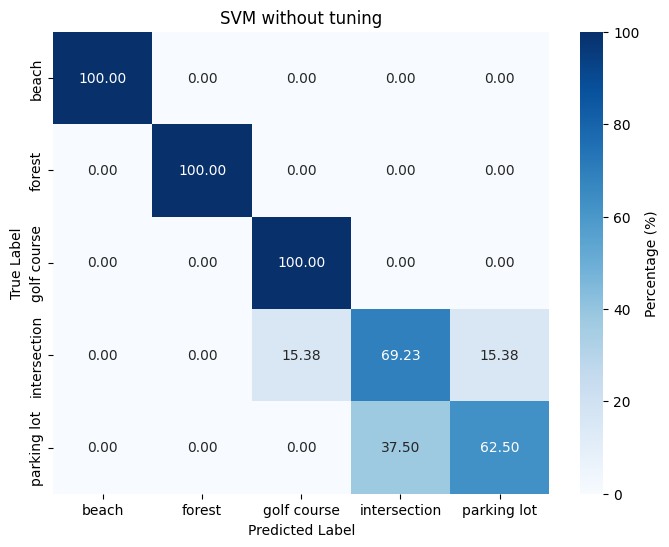

In [70]:
# Call the confusion_matrix_helper function to generate and display the confusion matrix
confusion_matrix_helper(test_land_cover_labels, 
                        predicted_labels_svm1, 
                        'SVM without tuning'
                        )

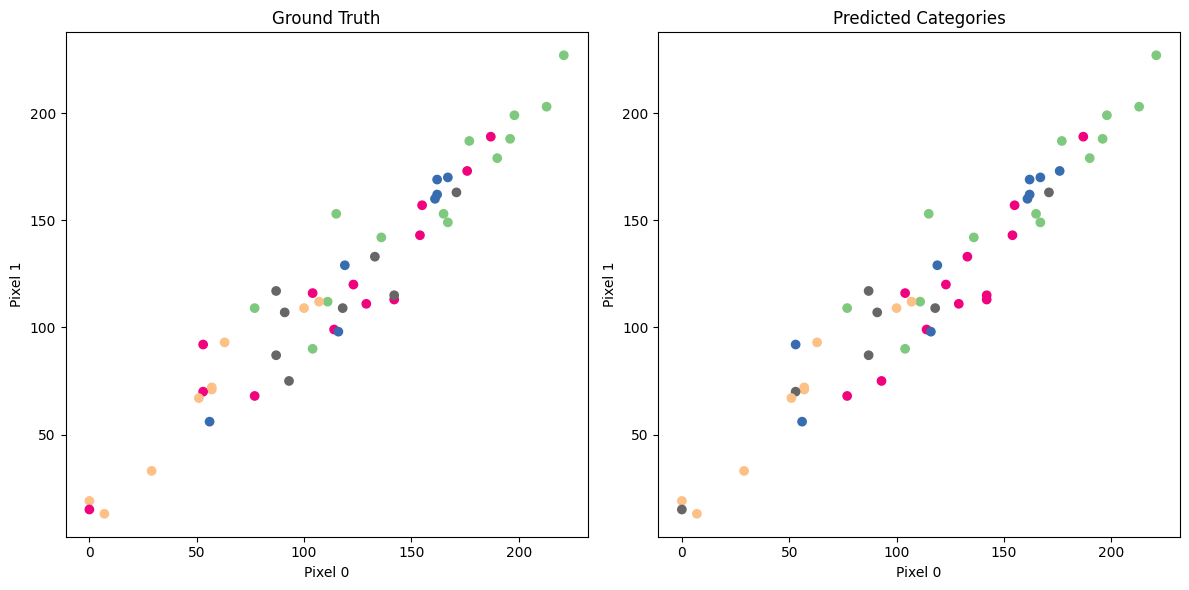

In [ ]:
# Call the scatter_plot2D function to create a 2D scatter plot
scatter_plot2D(test_land_cover_data_reshaped, 
               test_land_cover_labels, 
               predicted_labels_svm1,
               'Pixel 0',
               'Pixel 1'
               )

### <a id='toc6_5_2_'></a>[With Normalization and hyper parameter tuning](#toc0_)

In [20]:
# Normalize the training and testing data by scaling pixel values to the range [0, 1] by dividing by 255
normalized_train_data = train_land_cover_data_reshaped/255
normalized_test_data = test_land_cover_data_reshaped/255

In [ ]:
# Create an instance of the Support Vector Classifier (SVC) with RBF kernel and regularization parameter C=3
svm2 = SVC(kernel='rbf', C=3)

# Train the SVM model using the normalized training data and corresponding labels
svm2.fit(normalized_train_data, train_land_cover_labels)

# Predict the labels for the normalized test data using the trained SVM model
predicted_labels_svm2 = svm2.predict(normalized_test_data)

# Calculate and print the accuracy of the SVM model on the normalized test data
print(f"Accuracy:", svm2.score(normalized_test_data, test_land_cover_labels))

Accuracy: 0.88


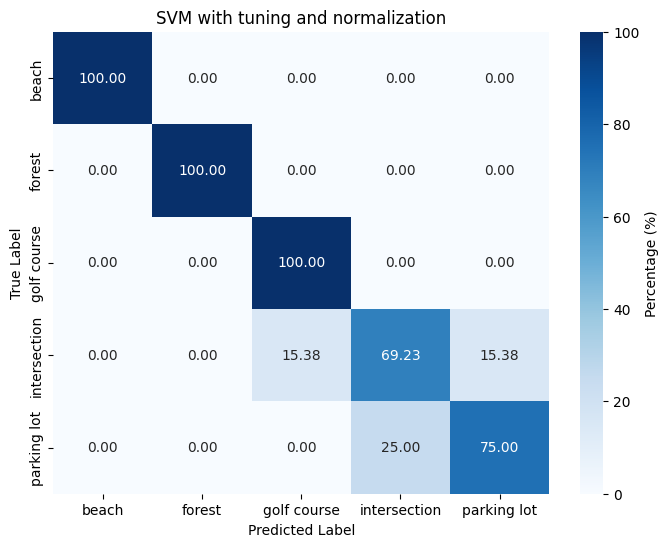

In [164]:
# Call the confusion_matrix_helper function to generate and display the confusion matrix
confusion_matrix_helper(test_land_cover_labels, 
                        predicted_labels_svm2, 
                        'SVM with tuning and normalization'
                        )

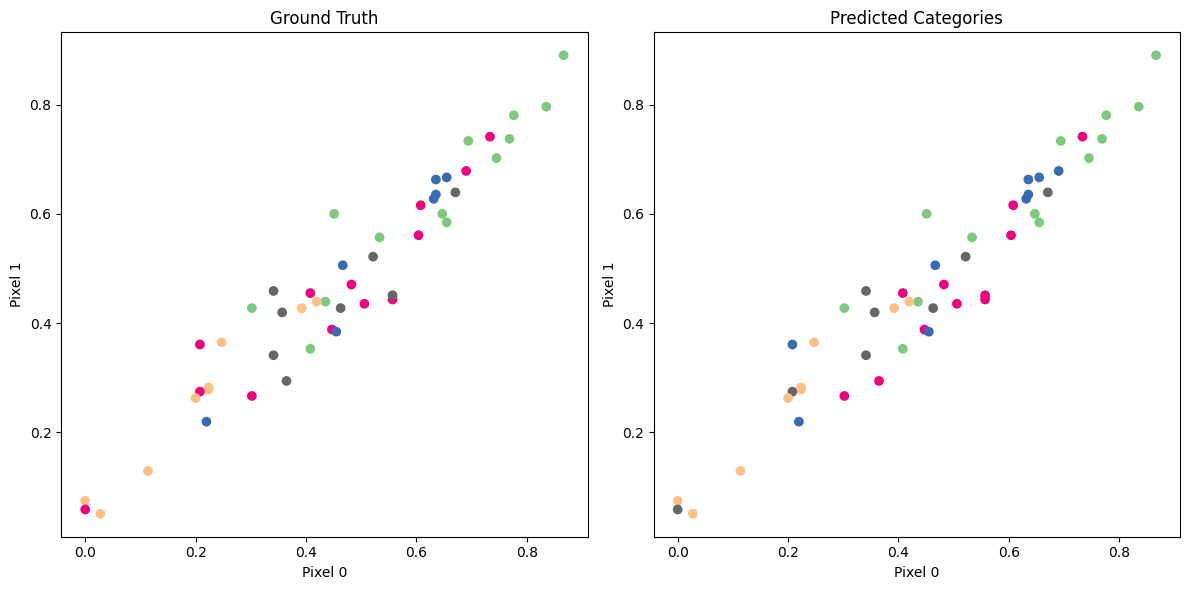

In [22]:
# Call the scatter_plot2D function to create a 2D scatter plot
scatter_plot2D(normalized_test_data, 
               test_land_cover_labels, 
               predicted_labels_svm2,
               'Pixel 0',
               'Pixel 1'
               )

# <a id='toc7_'></a>[Model 2 - Preprocessing with classification](#toc0_)

## <a id='toc7_1_'></a>[Pre-processing with LDA feature/dimensionality reduction](#toc0_)

In [23]:
# Create an instance of Linear Discriminant Analysis (LDA) with 4 components
lda1 = LDA(n_components=4)

# Apply LDA to transform the reshaped training data into a lower-dimensional space based on the labels
train_land_cover_data_transformed1 = lda1.fit_transform(train_land_cover_data_reshaped, train_land_cover_labels)

# Transform the reshaped test data using the same LDA transformation learned from the training data
test_land_cover_data_transformed1 = lda1.transform(test_land_cover_data_reshaped)


#### <a id='toc7_1_1_1_'></a>[Logistic regression](#toc0_)

In [28]:
# Train a classifier on the reduced training data
logistic_classifier4 = LogisticRegression(max_iter=1000)
logistic_classifier4.fit(train_land_cover_data_transformed1, train_land_cover_labels)

# Predict labels for the reduced test data
predicted_labels_lr4 = logistic_classifier4.predict(test_land_cover_data_transformed1)

print("Accuracy:", logistic_classifier4.score(test_land_cover_data_transformed1, 
                                              test_land_cover_labels))

Accuracy: 0.62


#### <a id='toc7_1_1_2_'></a>[SVM](#toc0_)

In [24]:
# Create an instance of the Support Vector Classifier (SVC)
svm3 = SVC()

# Train the SVM model using the transformed training data (after LDA) and corresponding labels
svm3.fit(train_land_cover_data_transformed1, train_land_cover_labels)

# Predict the labels for the transformed test data (after LDA) using the trained SVM model
predicted_labels_svm3 = svm3.predict(test_land_cover_data_transformed1)

# Calculate and print the accuracy of the SVM model on the transformed test data
print(f"Accuracy:", svm3.score(test_land_cover_data_transformed1, test_land_cover_labels))

Accuracy: 0.56


#### <a id='toc7_1_1_3_'></a>[Confusion matrix and visualizations](#toc0_)

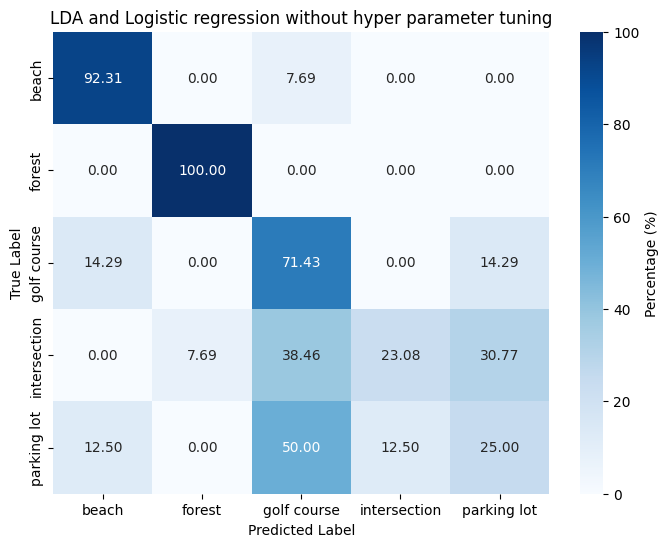

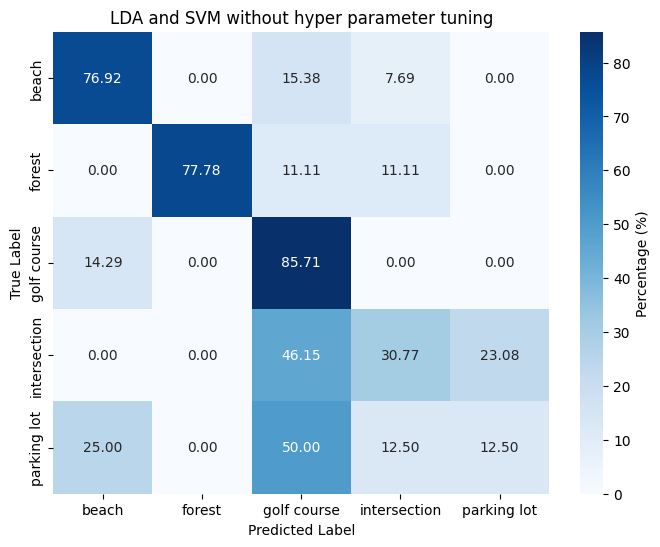

In [29]:
# Call the confusion_matrix_helper function to generate and display the confusion matrix
confusion_matrix_helper(test_land_cover_labels, predicted_labels_lr4, 'LDA and Logistic regression without hyper parameter tuning')
confusion_matrix_helper(test_land_cover_labels, predicted_labels_svm3, 'LDA and SVM without hyper parameter tuning')

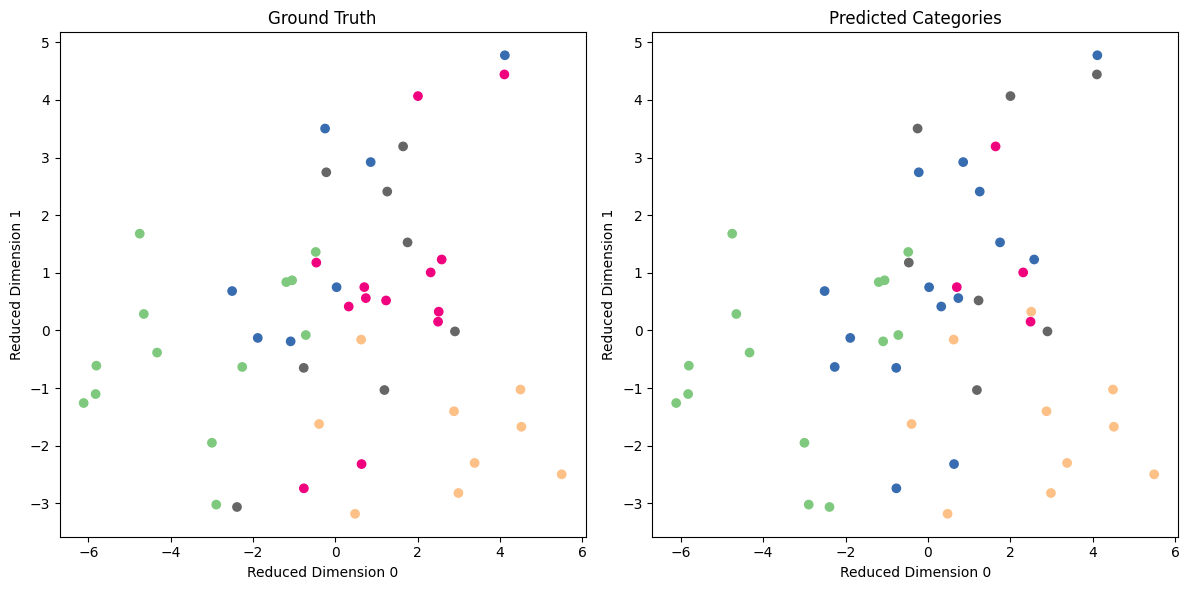

In [30]:
# Call the scatter_plot2D function to create a 2D scatter plot
scatter_plot2D(test_land_cover_data_transformed1, 
               test_land_cover_labels, 
               predicted_labels_lr4,
               'Reduced Dimension 0',
               'Reduced Dimension 1'
               )

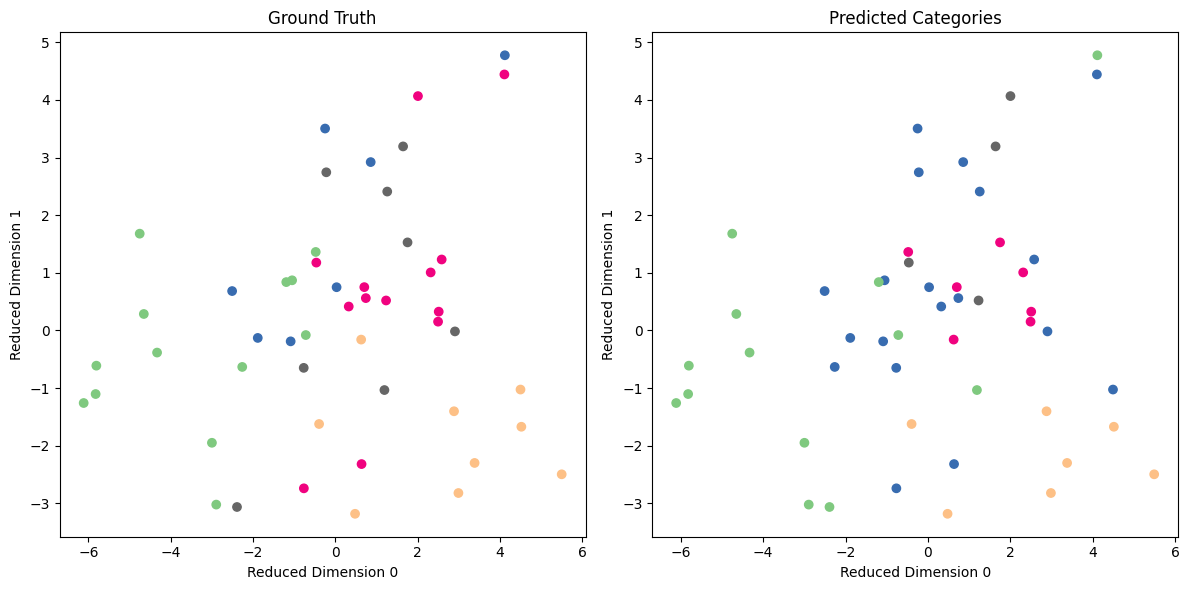

In [26]:
# Call the scatter_plot2D function to create a 2D scatter plot
scatter_plot2D(test_land_cover_data_transformed1, 
               test_land_cover_labels, 
               predicted_labels_svm3,
               'Reduced Dimension 0',
               'Reduced Dimension 1'
               )


## <a id='toc7_2_'></a>[Pre-processing with HOG feature extraction reduction](#toc0_)

In [32]:
# Initialize an empty list to store the HOG features for each image
hog_features = []

# Iterate over each image in the selected_land_cover_data
for image in np.array(selected_land_cover_data):
    # Extract HOG features and the corresponding HOG image using specified parameters
    hog_feature, hog_image = skimage.feature.hog(image, 
                                                 pixels_per_cell=[10, 10], 
                                                 cells_per_block=[5, 5], 
                                                 visualize=True,
                                                 channel_axis=2
                                                )

    # Append the HOG features to the hog_features list
    hog_features.append(hog_feature)

In [33]:
# Split the HOG features and corresponding labels into training and testing sets
# Use 10% of the data for testing, shuffle the data, and set a random seed for reproducibility
split_list_post_hog = train_test_split(hog_features,
                                       selected_land_cover_labels,
                                       test_size=0.1,
                                       shuffle=True,
                                       random_state=seeding_constant
                                      )

# Extract the training data (HOG features) from the split result
train_data_post_hog = np.array(split_list_post_hog[0])

# Extract the testing data (HOG features) from the split result
test_data_post_hog = np.array(split_list_post_hog[1])

# Extract the training labels from the split result
train_labels_post_hog = np.array(split_list_post_hog[2])

# Extract the testing labels from the split result
test_labels_post_hog = np.array(split_list_post_hog[3])


### <a id='toc7_2_1_'></a>[Logistic Regression](#toc0_)

In [34]:
# Create an instance of the Logistic Regression classifier
logistic_classifier7 = LogisticRegression()

# Train the logistic regression model using the HOG features from the training data and corresponding labels
logistic_classifier7.fit(train_data_post_hog, train_labels_post_hog)

# Predict the labels for the reduced test data using the trained logistic regression model
predicted_labels_lr7 = logistic_classifier7.predict(test_data_post_hog)

# Calculate and print the accuracy of the logistic regression model on the test data
print(f"Accuracy: {logistic_classifier7.score(test_data_post_hog, test_labels_post_hog)}")

Accuracy: 0.9


### <a id='toc7_2_2_'></a>[SVM](#toc0_)

In [35]:
# Create an instance of the Support Vector Classifier (SVC)
svm6 = SVC()

# Train the SVM model using the HOG features from the training data and corresponding labels
svm6.fit(train_data_post_hog, train_labels_post_hog)

# Predict the labels for the reduced test data using the trained SVM model
predicted_labels_svm6 = svm6.predict(test_data_post_hog)

# Calculate and print the accuracy of the SVM model on the test data
print(f"Accuracy:", svm6.score(test_data_post_hog, test_labels_post_hog))

Accuracy: 0.9


### <a id='toc7_2_3_'></a>[Confusion matrix and visualisations](#toc0_)

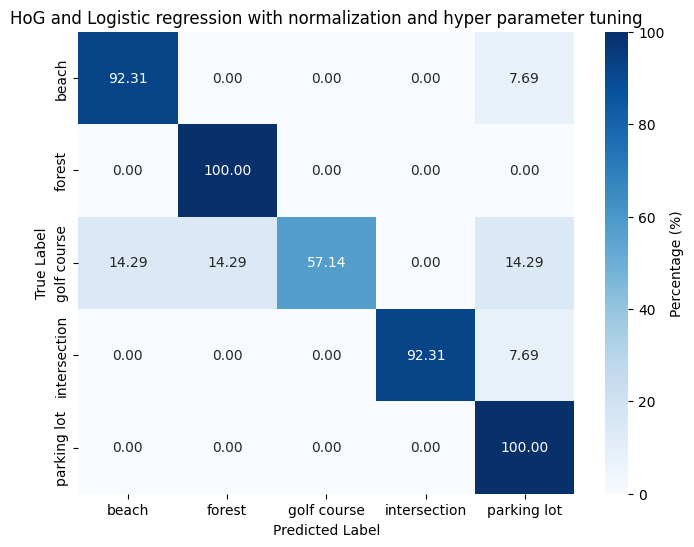

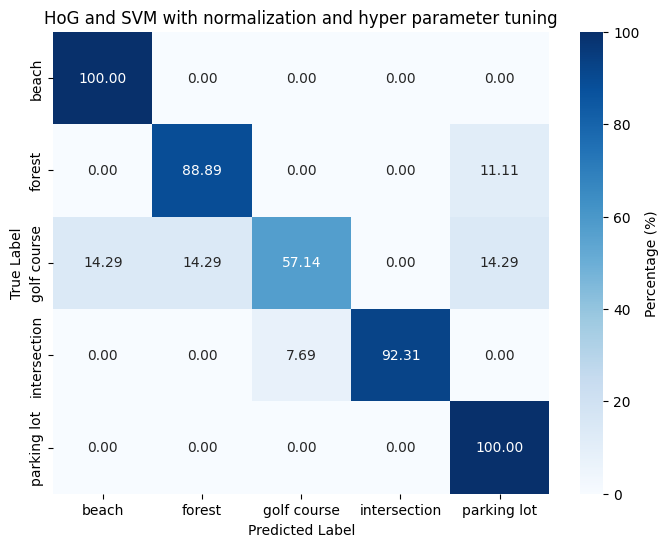

In [36]:
# Call the confusion_matrix_helper function to generate and display the confusion matrix
confusion_matrix_helper(test_labels_post_hog, 
                        predicted_labels_lr7, 
                        'HoG and Logistic regression with normalization and hyper parameter tuning'
                        )

confusion_matrix_helper(test_labels_post_hog, 
                        predicted_labels_svm6, 
                        'HoG and SVM with normalization and hyper parameter tuning'
                        )

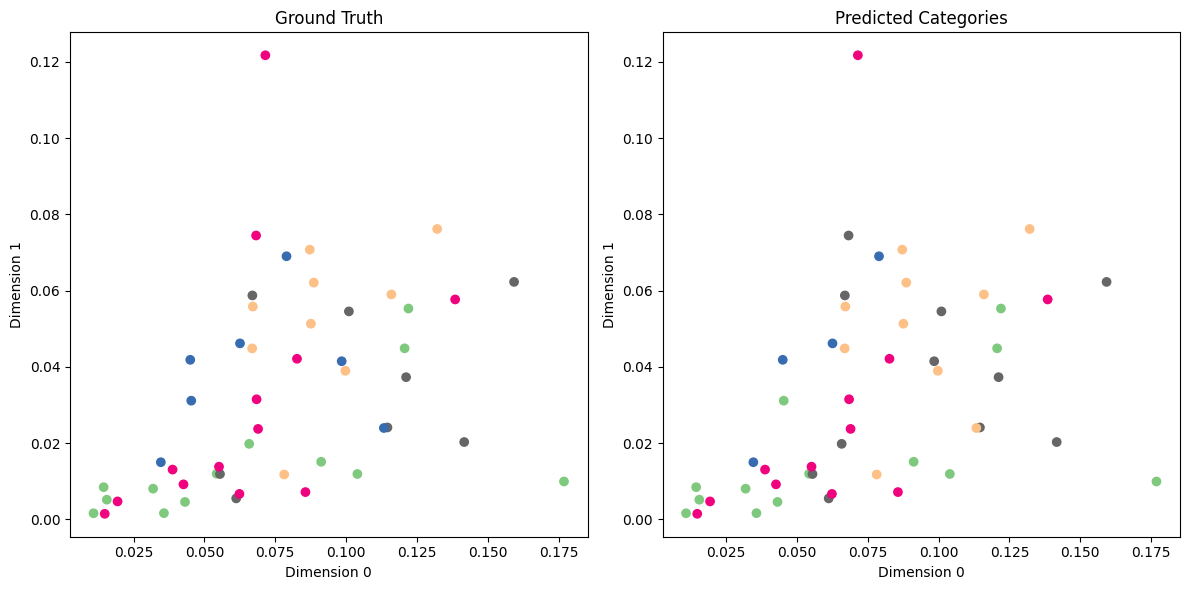

In [37]:
# Call the scatter_plot2D function to create a 2D scatter plot
scatter_plot2D(test_data_post_hog, 
               test_labels_post_hog, 
               predicted_labels_lr7,
               'Dimension 0',
               'Dimension 1'
               )

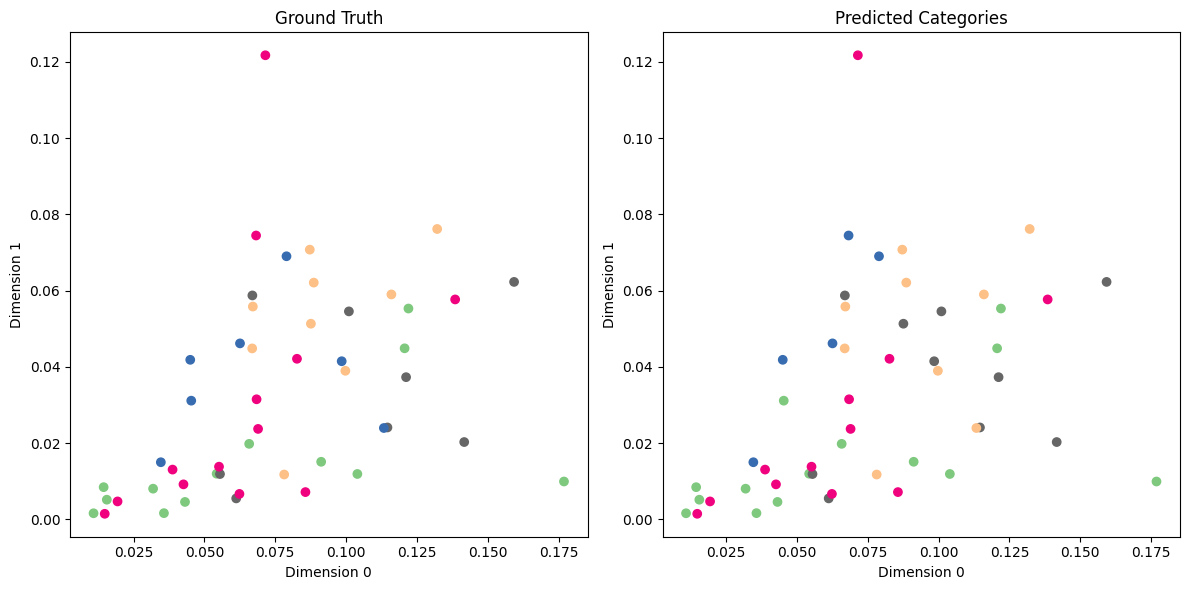

In [38]:
# Call the scatter_plot2D function to create a 2D scatter plot
scatter_plot2D(test_data_post_hog, 
               test_labels_post_hog, 
               predicted_labels_svm6,
               'Dimension 0',
               'Dimension 1'
               )

# <a id='toc8_'></a>[Model 3 - CNN](#toc0_)

## <a id='toc8_1_'></a>[Model 3A - CNN without data agumentation](#toc0_)

### <a id='toc8_1_1_'></a>[Split Data and its overview](#toc0_)

In [39]:
# Split the land cover data and corresponding labels into training and testing sets
# Use 20% of the data for testing, shuffle the data, and set a random seed for reproducibility
split_list_cnn = train_test_split(land_cover_data,
                                  land_cover_labels,
                                  test_size=0.2,
                                  shuffle=True,
                                  random_state=seeding_constant
                                 )

# Extract the training data and corresponding labels from the split result
train_cnn_data = split_list_cnn[0]
train_cnn_labels = split_list_cnn[2]

# Extract the testing data and corresponding labels from the split result (10% of the original data for testing)
test_cnn_data = split_list_cnn[1]
test_cnn_labels = split_list_cnn[3]


In [40]:
# Get the unique labels from the training data labels
unique_train_cnn_labels = set(np.unique(train_cnn_labels))

# Print the count of each label in the training data to show the data diversification
print("Train Data diversification")
for i in unique_train_cnn_labels:
    # For each label, count how many times it appears in the training labels and print the result
    print(f"Label {i} : {list(train_cnn_labels).count(i)}")


Train Data diversification
Label 0 : 83
Label 1 : 82
Label 2 : 76
Label 3 : 79
Label 4 : 74
Label 5 : 78
Label 6 : 79
Label 7 : 75
Label 8 : 74
Label 9 : 81
Label 10 : 86
Label 11 : 85
Label 12 : 90
Label 13 : 78
Label 14 : 83
Label 15 : 81
Label 16 : 84
Label 17 : 79
Label 18 : 79
Label 19 : 80
Label 20 : 74


In [41]:
# Get the unique labels from the test data labels
unique_test_cnn_labels = np.unique(test_cnn_labels)

# Print the count of each label in the test data to show the data diversification
print("Test Data diversification")
for i in unique_test_cnn_labels:
    # For each label, count how many times it appears in the test labels and print the result
    print(f"Label {i} : {list(test_cnn_labels).count(i)}")


Test Data diversification
Label 0 : 17
Label 1 : 18
Label 2 : 24
Label 3 : 21
Label 4 : 26
Label 5 : 22
Label 6 : 21
Label 7 : 25
Label 8 : 26
Label 9 : 19
Label 10 : 14
Label 11 : 15
Label 12 : 10
Label 13 : 22
Label 14 : 17
Label 15 : 19
Label 16 : 16
Label 17 : 21
Label 18 : 21
Label 19 : 20
Label 20 : 26


### <a id='toc8_1_2_'></a>[CNN](#toc0_)

In [42]:
# Normalize the training data by scaling pixel values to the range [0, 1] by dividing by 255
normalized_cnn_train_data = train_cnn_data / 255

# Normalize the test data by scaling pixel values to the range [0, 1] by dividing by 255
normalized_cnn_test_data = test_cnn_data / 255


In [44]:
#Filter variables for cnn
filter_count = 32
multiplier=0

#Define the model with layers and hyperparams as per requiremnets
model_cnn = tf.keras.Sequential(layers=[
    tf.keras.layers.Conv2D(filter_count, kernel_size=(3,3), activation=tf.nn.leaky_relu),    
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+1)), kernel_size=(3,3), activation=tf.nn.relu),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+1)), kernel_size=(3,3), activation=tf.nn.relu, use_bias=True),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+2)), kernel_size=(3,3), activation=tf.nn.elu, use_bias=True),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(filter_count*(2**(multiplier+4)), activation=tf.nn.elu, use_bias=True),
    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Dense(len(np.unique(land_cover_labels)), activation = tf.nn.softmax)])

#Add the optimizer, loss, metrics and finalize the configuration
model_cnn.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics = [tf.keras.metrics.SparseCategoricalAccuracy()])

#Train the model with train data set and include validation to see the accuracy
history_cnn = model_cnn.fit(normalized_cnn_train_data,
                            train_cnn_labels,
                            epochs = 20,
                            validation_split = 0.1,
                            verbose = 1
                            )

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 4.1069 - sparse_categorical_accuracy: 0.1438 - val_loss: 3.0476 - val_sparse_categorical_accuracy: 0.0833
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 2.3568 - sparse_categorical_accuracy: 0.3396 - val_loss: 3.2035 - val_sparse_categorical_accuracy: 0.0536
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 1.7620 - sparse_categorical_accuracy: 0.4660 - val_loss: 3.4639 - val_sparse_categorical_accuracy: 0.0833
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 1.4858 - sparse_categorical_accuracy: 0.5504 - val_loss: 3.4924 - val_sparse_categorical_accuracy: 0.0298
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 1.1206 - sparse_categorical_accuracy: 0.6406 - val_loss: 3.5081 - val_sparse_categorical_accuracy: 0.0893
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.9319 - sparse_categorical_accuracy: 0.7295 - val_loss: 3.5252 - val_sparse_categorical_accuracy: 0.0774
Epoch 7/20

In [45]:
# Display the summary of the CNN model, which includes details about its layers, output shapes, and number of parameters
model_cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 59, 59, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 59, 59, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 29, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 27, 27, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,638,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │        10,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,340,865 (20.37 MB)

 Trainable params: 1,780,181 (6.79 MB)

 Non-trainable params: 320 (1.25 KB)

 Optimizer params: 3,560,364 (13.58 MB)

In [ ]:
#Use the testing data to check the accuraccy and if the model needs any tuning
results_cnn = model_cnn.evaluate(normalized_cnn_test_data, test_cnn_labels)

print(f'Test set loss: {results_cnn[0]:0.2f}, test set accuracy: {results_cnn[1]*100:0.2f}%')

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.2604 - sparse_categorical_accuracy: 0.6535
Test set loss: 1.24, test set accuracy: 63.81%


### <a id='toc8_1_3_'></a>[Confusion matrix and visualisations](#toc0_)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


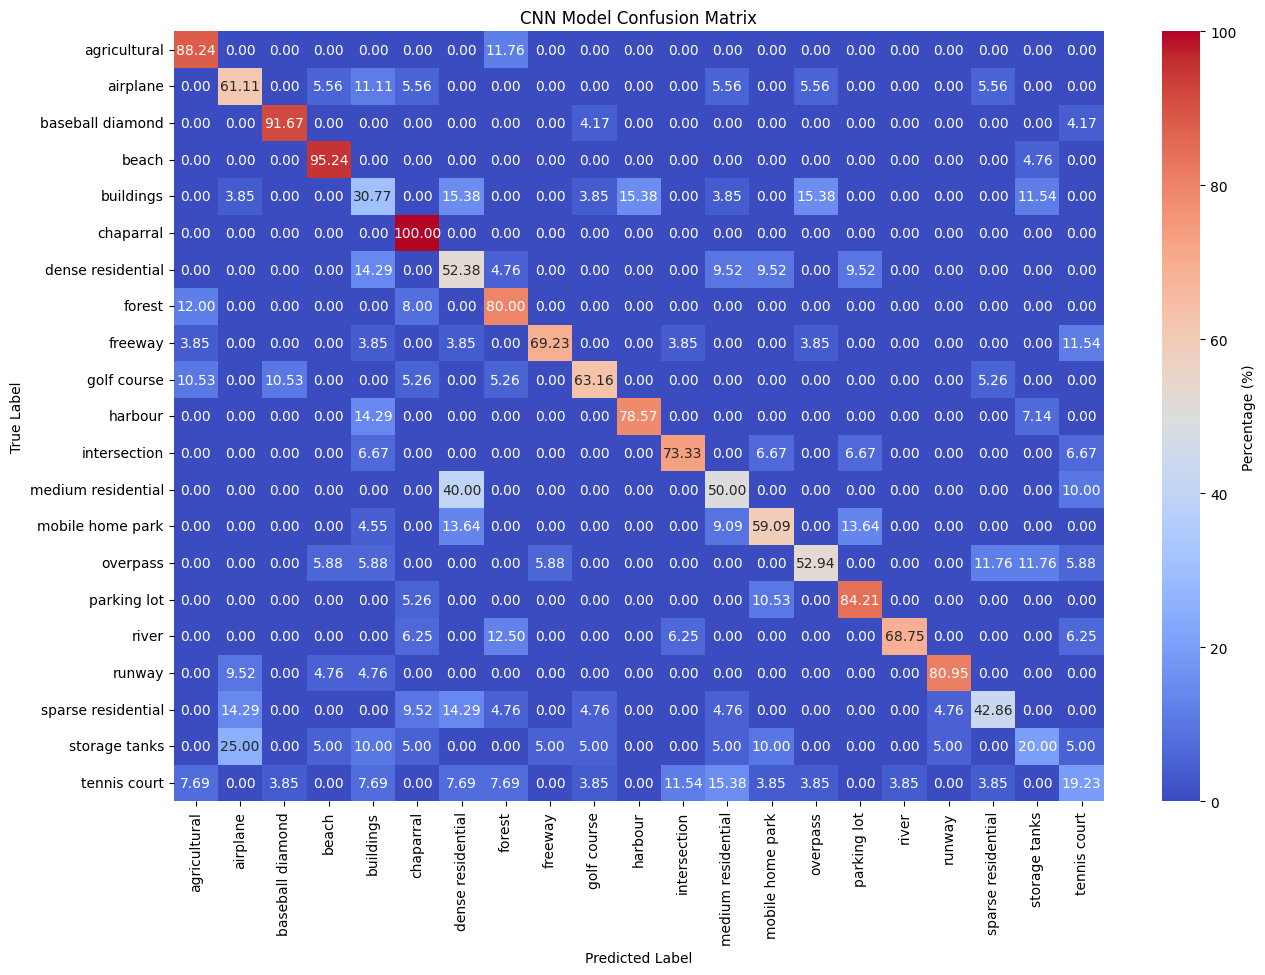

In [48]:
# Use the trained CNN model to predict labels for the normalized test data
predicted_labels_matrix = model_cnn.predict(normalized_cnn_test_data)

# Convert the predicted labels from one-hot encoding to class labels using argmax
predicted_labels_cnn = np.argmax(predicted_labels_matrix, axis=1)

# Call the confusion_matrix_helper function to generate and display the confusion matrix for the CNN model
# Pass the true labels (test_cnn_labels), predicted labels (predicted_labels_cnn), and additional parameters for customization
confusion_matrix_helper(test_cnn_labels, 
                        predicted_labels_cnn, 
                        'CNN Model Confusion Matrix', 
                        figure_size=(15, 10),
                        color_map='coolwarm'
                        )


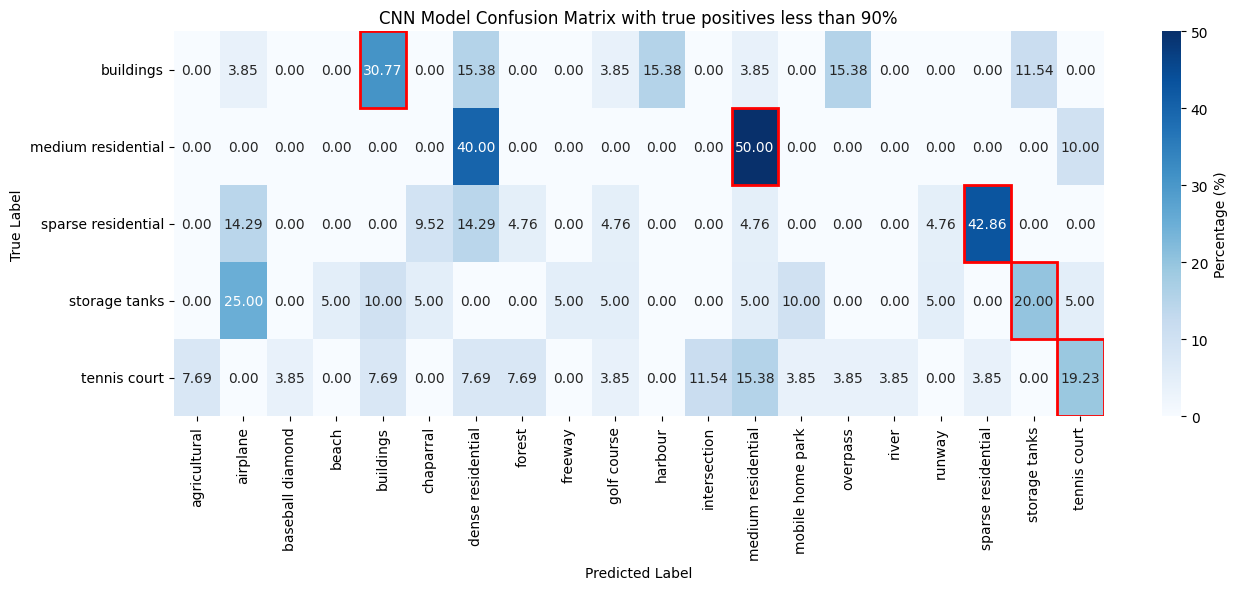

In [ ]:
# Call the confusion_matrix_helper_threshold function to generate and display the confusion matrix with a threshold applied
confusion_matrix_helper_threshold(test_cnn_labels, 
                        predicted_labels_cnn, 
                        'CNN Model Confusion Matrix with true positives less than 90%', 
                        label_classes,
                        operator='LTE',
                        figure_size=(15, 5),
                        )

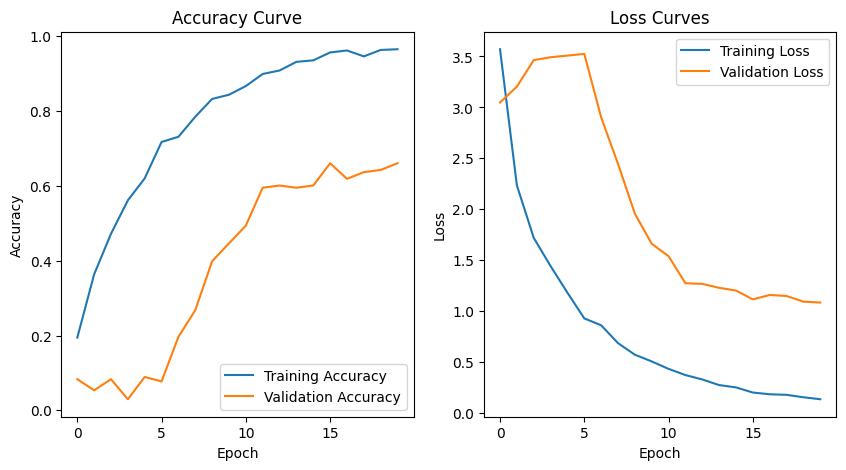

In [51]:
# Set the figure size for the plot
plt.figure(figsize=[10, 5])

# Plot lines for training vs validation accuracy
plt.subplot(121)
plt.plot(history_cnn.history['sparse_categorical_accuracy'])
plt.plot(history_cnn.history['val_sparse_categorical_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.title('Accuracy Curve')

# Plot lines for training vs validation loss
plt.subplot(122)
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])
plt.title('Loss Curves')

# Display the plots
plt.show()


## <a id='toc8_2_'></a>[Model 3B - CNN with data agumentation](#toc0_)

### <a id='toc8_2_1_'></a>[Split agumented data](#toc0_)

In [52]:
# Split the augmented images and corresponding labels into training and testing sets
# Use 10% of the augmented data for testing, shuffle the data, and set a random seed for reproducibility
split_list_cnn_augmented = train_test_split(augmented_images,
                                            augmented_label_list,
                                            test_size=0.1,
                                            shuffle=True,
                                            random_state=seeding_constant
                                           )

# Extract the augmented training data and corresponding labels from the split result
train_cnn_data_augmented = split_list_cnn_augmented[0]
train_cnn_labels_augmented = split_list_cnn_augmented[2]

# Extract the augmented testing data and corresponding labels from the split result
test_cnn_data_augmented = split_list_cnn_augmented[1]
test_cnn_labels_augmented = split_list_cnn_augmented[3]


### <a id='toc8_2_2_'></a>[Visualising augmented images](#toc0_)


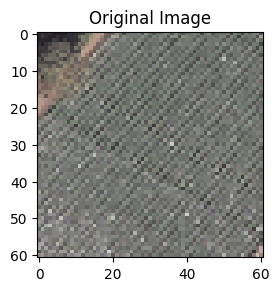

In [53]:
# Create a new figure for the plot
plt.figure()

# Plot the first image from the land cover data in the first subplot
plt.subplot(121)
plt.imshow(land_cover_data[0])  # Display the original image
plt.title('Original Image')  # Title for the subplot

# Show the plot
plt.show()


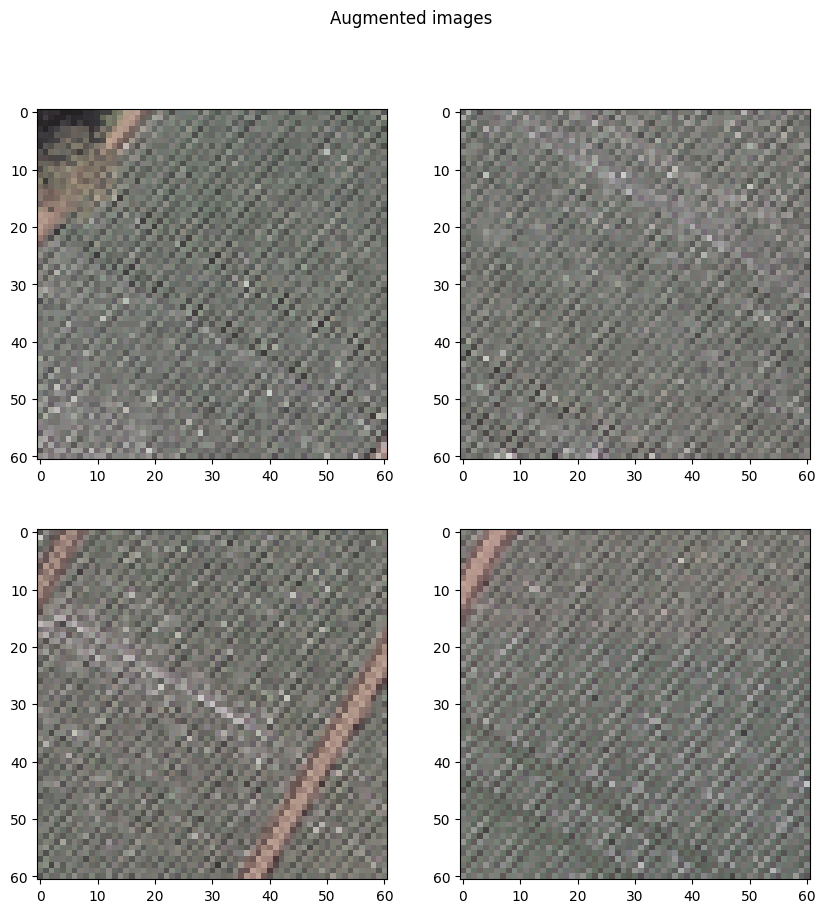

In [56]:
# Create a new figure with a specified size for the plot
plt.figure(figsize=(10, 10))

# Set a title for the entire figure
plt.suptitle('Augmented images')

# Plot the first augmented image in the first subplot
plt.subplot(2, 2, 1)
plt.imshow(augmented_images[0] / 255)  # Normalize the image by dividing by 255

# Plot the second augmented image in the second subplot
plt.subplot(2, 2, 2)
plt.imshow(augmented_images[1] / 255)  # Normalize the image by dividing by 255

# Plot the third augmented image in the third subplot
plt.subplot(2, 2, 3)
plt.imshow(augmented_images[2] / 255)  # Normalize the image by dividing by 255

# Plot the fourth augmented image in the fourth subplot
plt.subplot(2, 2, 4)
plt.imshow(augmented_images[3]/255)

plt.show()


### <a id='toc8_2_3_'></a>[Understanding Split Data](#toc0_)

In [57]:
# Get the unique labels from the augmented training data labels
unique_train_cnn_labels = set(np.unique(train_cnn_labels_augmented))

print("Train Data diversification")
for i in unique_train_cnn_labels:
    print(f"Label {i} : {list(train_cnn_labels_augmented).count(i)}")

Train Data diversification
Label 0 : 1884
Label 1 : 1889
Label 2 : 1899
Label 3 : 1911
Label 4 : 1896
Label 5 : 1902
Label 6 : 1874
Label 7 : 1889
Label 8 : 1891
Label 9 : 1909
Label 10 : 1870
Label 11 : 1897
Label 12 : 1874
Label 13 : 1884
Label 14 : 1891
Label 15 : 1872
Label 16 : 1867
Label 17 : 1883
Label 18 : 1910
Label 19 : 1908
Label 20 : 1890


In [ ]:
# Get the unique labels from the augmented testing data labels
unique_test_cnn_labels = np.unique(test_cnn_labels_augmented)

print("Test Data diversification")
for i in unique_test_cnn_labels:
    print(f"Label {i} : {list(test_cnn_labels_augmented).count(i)}")

Test Data diversification
Label 0 : 216
Label 1 : 211
Label 2 : 201
Label 3 : 189
Label 4 : 204
Label 5 : 198
Label 6 : 226
Label 7 : 211
Label 8 : 209
Label 9 : 191
Label 10 : 230
Label 11 : 203
Label 12 : 226
Label 13 : 216
Label 14 : 209
Label 15 : 228
Label 16 : 233
Label 17 : 217
Label 18 : 190
Label 19 : 192
Label 20 : 210


### <a id='toc8_2_4_'></a>[CNN defination and training](#toc0_)

In [129]:
# Normalize the augmented training data by scaling pixel values to the range [0, 1] by dividing by 255
normalized_cnn_train_data_augmented = train_cnn_data_augmented / 255

# Normalize the augmented test data by scaling pixel values to the range [0, 1] by dividing by 255
normalized_cnn_test_data_augmented = test_cnn_data_augmented / 255


In [130]:
#Filter variables for cnn
filter_count = 32
multiplier=0

early_stopping = EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True, verbose=1)


#Define the model with layers and hyperparams as per requiremnets
model_cnn_augmented = tf.keras.Sequential(layers=[
    tf.keras.layers.Conv2D(filter_count, kernel_size=(3,3), activation=tf.nn.leaky_relu),    
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+1)), kernel_size=(3,3), activation=tf.nn.relu),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+1)), kernel_size=(3,3), activation=tf.nn.relu, use_bias=True),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(filter_count*(2**(multiplier+2)), kernel_size=(3,3), activation=tf.nn.elu, use_bias=True),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(filter_count*(2**(multiplier+4)), activation=tf.nn.elu, use_bias=True),
    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Dense(len(np.unique(land_cover_labels)), activation = tf.nn.softmax)])

#Add the optimizer, loss, metrics and finalize the configuration
model_cnn_augmented.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics = [tf.keras.metrics.SparseCategoricalAccuracy()])

#Train the model with train data set and include validation to see the accuracy
history_cnn_augmeneted = model_cnn_augmented.fit(normalized_cnn_train_data_augmented,
                                train_cnn_labels_augmented,
                                epochs = 8,
                                validation_split = 0.1,
                                verbose = 1,
                                callbacks=[early_stopping]
                                )

Epoch 1/8
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 78s 66ms/step - loss: 2.3244 - sparse_categorical_accuracy: 0.3785 - val_loss: 0.7728 - val_sparse_categorical_accuracy: 0.7561
Epoch 2/8
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 180s 154ms/step - loss: 0.8717 - sparse_categorical_accuracy: 0.7172 - val_loss: 0.4999 - val_sparse_categorical_accuracy: 0.8335
Epoch 3/8
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 201s 152ms/step - loss: 0.5465 - sparse_categorical_accuracy: 0.8183 - val_loss: 0.3715 - val_sparse_categorical_accuracy: 0.8811
Epoch 4/8
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 199s 149ms/step - loss: 0.3744 - sparse_categorical_accuracy: 0.8752 - val_loss: 0.2661 - val_sparse_categorical_accuracy: 0.9133
Epoch 5/8
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 164s 147ms/step - loss: 0.2668 - sparse_categorical_accuracy: 0.9074 - val_loss: 0.2175 - val_sparse_categorical_accuracy: 0.9289
Epoch 6/8
1117/1117 ━━━━━━━━━━━━━━━━━━━━ 181s 162ms/step - loss: 0.2180 - sparse_categorical_accuracy: 0.9272 - val_loss: 0.2072 - val_sparse_categ

In [131]:
# Display the summary of the CNN model for the augmented data, which includes details about its layers, output shapes, and number of parameters
model_cnn_augmented.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 59, 59, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 59, 59, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 29, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 27, 27, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 27, 27, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 25, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,638,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 21)             │        10,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,340,865 (20.37 MB)

 Trainable params: 1,780,181 (6.79 MB)

 Non-trainable params: 320 (1.25 KB)

 Optimizer params: 3,560,364 (13.58 MB)

In [ ]:
#Use the testing data to check the accuraccy and if the model needs any tuning
results_cnn_augmented = model_cnn_augmented.evaluate(normalized_cnn_test_data_augmented, test_cnn_labels_augmented)

print(f'Test set loss: {results_cnn_augmented[0]:0.2f}, test set accuracy: {results_cnn_augmented[1]*100:0.2f}%')

138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1259 - sparse_categorical_accuracy: 0.9596
Test set loss: 0.14, test set accuracy: 95.40%


### <a id='toc8_2_5_'></a>[Confusion matrix and accuracy curves](#toc0_)

138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


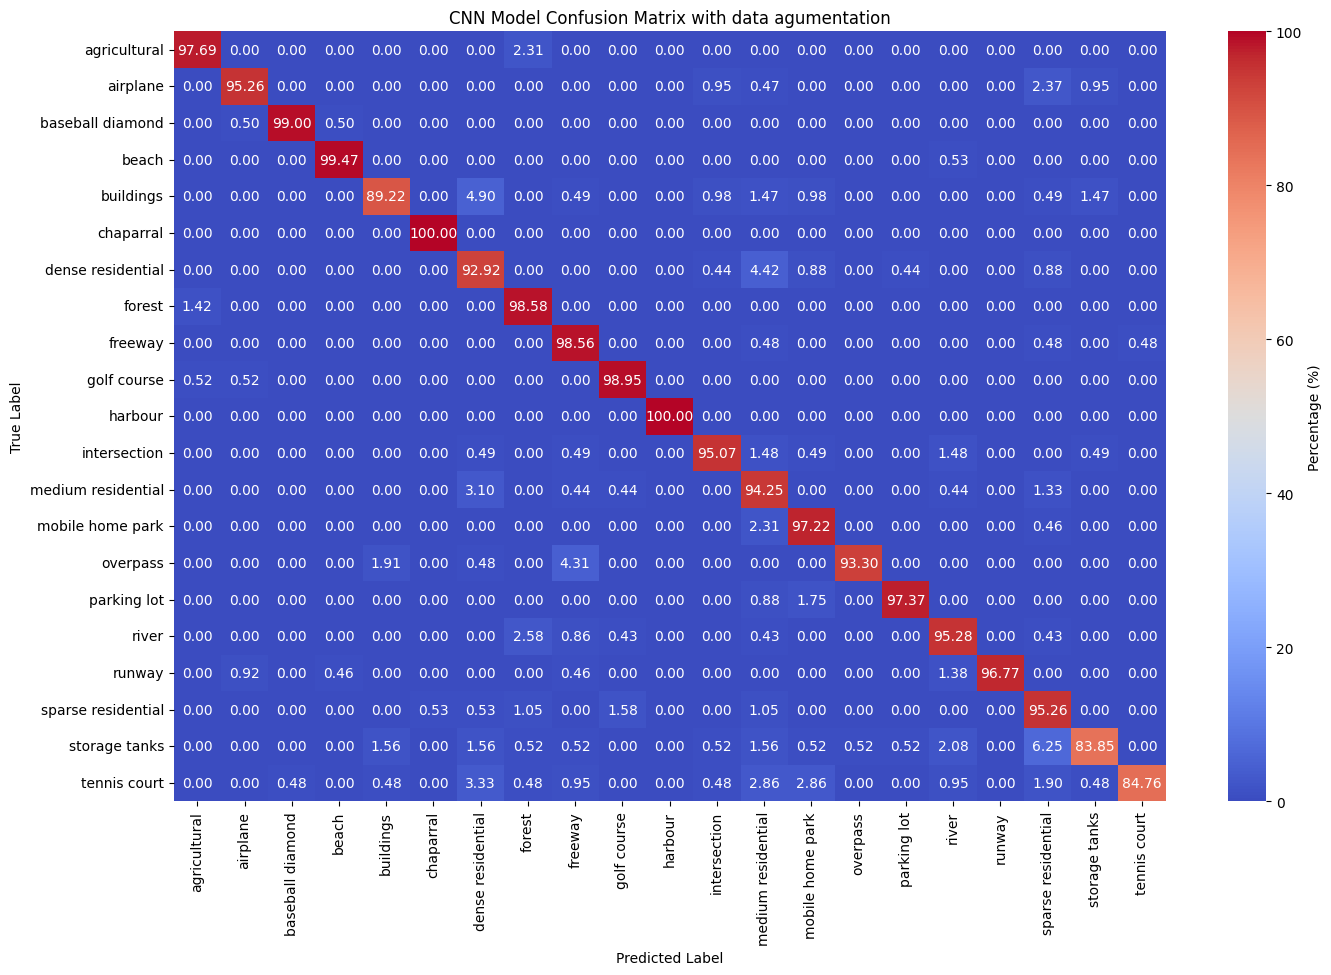

In [135]:
# Generate predictions and confusion matrix
predicted_labels_matrix_augmented = model_cnn_augmented.predict(normalized_cnn_test_data_augmented)
predicted_labels_cnn_augmented = np.argmax(predicted_labels_matrix_augmented, axis=1)

# Call the confusion_matrix_helper_threshold function to generate and display the confusion matrix 
confusion_matrix_helper(test_cnn_labels_augmented, 
                        predicted_labels_cnn_augmented, 
                        'CNN Model Confusion Matrix with data agumentation', 
                        figure_size=(16, 10),
                        color_map='coolwarm'
                        )


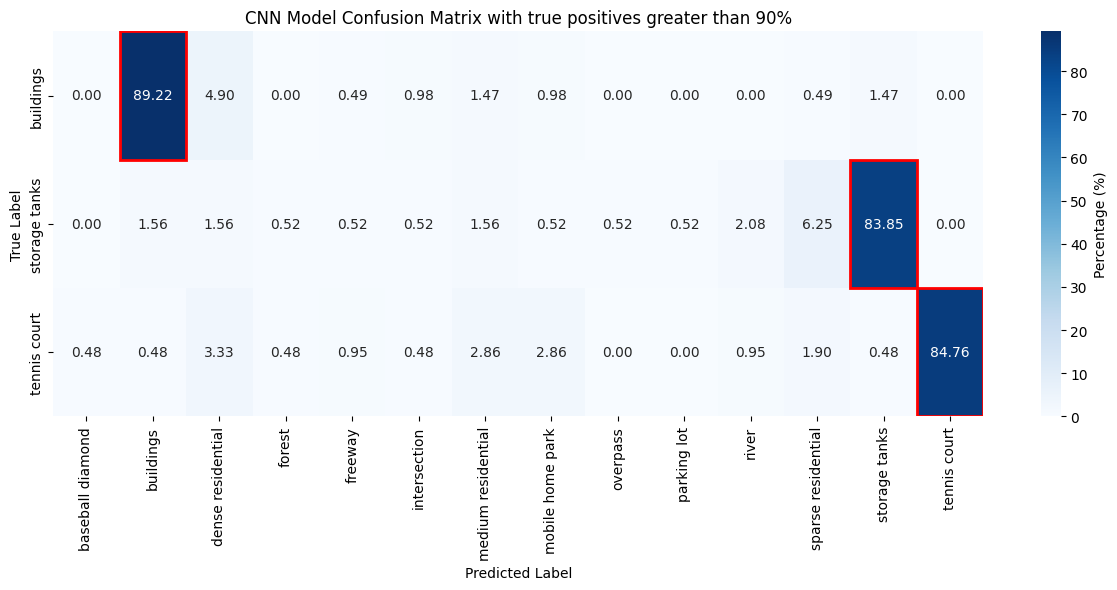

In [139]:
# Call the confusion_matrix_helper_threshold function to generate and display the confusion matrix with a threshold applied
confusion_matrix_helper_threshold(test_cnn_labels_augmented, 
                        predicted_labels_cnn_augmented, 
                        'CNN Model Confusion Matrix with true positives greater than 90%', 
                        label_classes,
                        operator='LTE',
                        threshold=90,
                        figure_size=(15, 5)
                        )


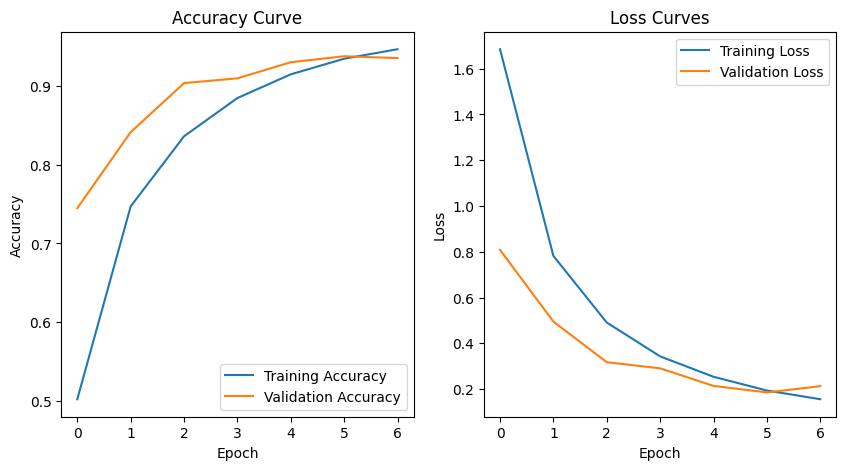

In [ ]:
plt.figure(figsize=[10,5])

#Plot lines for training vs validation accuracy
plt.subplot(121)
plt.plot(history_cnn_augmeneted.history['sparse_categorical_accuracy'])
plt.plot(history_cnn_augmeneted.history['val_sparse_categorical_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy',
           'Validation Accuracy'])
plt.title('Accuracy Curve')

#Plot lines for training vs validation loss
plt.subplot(122)
plt.plot(history_cnn_augmeneted.history['loss'])
plt.plot(history_cnn_augmeneted.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss',
           'Validation Loss'])
plt.title('Loss Curves')

plt.show()